In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc

In [2]:
# =============================================================================
# DATA LOADING & PREPARATION
# =============================================================================

# STEP 1: Load the CSV files into Pandas DataFrames
labels = pd.read_csv('Train-1542865627584.csv')
beneficiary = pd.read_csv('Train_Beneficiarydata-1542865627584.csv')
inpatient = pd.read_csv('Train_Inpatientdata-1542865627584.csv')
outpatient = pd.read_csv('Train_Outpatientdata-1542865627584.csv')

In [3]:
# STEP 2: Create a binary flag to differentiate Inpatient from Outpatient claims
inpatient['Is_Inpatient'] = 1
outpatient['Is_Inpatient'] = 0

In [4]:
# STEP 3: Combine Inpatient and Outpatient datasets into one unified claims table
claims = pd.concat([inpatient, outpatient], axis=0, ignore_index=True)

In [5]:
# STEP 4: Clean up missing financial values
# Assumption: If a claim has no deductible or reimbursement listed, it is $0
claims['InscClaimAmtReimbursed'] = claims['InscClaimAmtReimbursed'].fillna(0.0)
claims['DeductibleAmtPaid'] = claims['DeductibleAmtPaid'].fillna(0.0)

In [6]:
# =============================================================================
# FEATURE ENGINEERING
# =============================================================================

# STEP 5: Calculate a "Patient Risk Score" based on chronic conditions
# Use list comprehension to quickly isolate columns representing chronic conditions
chronic_columns = [col for col in beneficiary.columns if 'ChronicCond' in col]

# Convert values: 1 ("Yes") remains 1, and 2 ("No") becomes 0 for easier math
beneficiary[chronic_columns] = beneficiary[chronic_columns].replace(2, 0)

# Aggregate conditions across rows to derive a total risk score per patient
beneficiary['Patient_Risk_Score'] = beneficiary[chronic_columns].sum(axis=1)

In [7]:
# STEP 6: Merge the calculated Patient Risk Score into the unified claims table
patient_subset = beneficiary[['BeneID', 'Patient_Risk_Score']]
claims_bene = pd.merge(claims, patient_subset, on='BeneID', how='left')

In [8]:
# STEP 7: Calculate the duration of each claim in days
claims_bene['ClaimStartDt'] = pd.to_datetime(claims_bene['ClaimStartDt'])
claims_bene['ClaimEndDt'] = pd.to_datetime(claims_bene['ClaimEndDt'])

# Add 1 to ensure same-day claims reflect as 1 day duration instead of 0
claims_bene['ClaimDuration'] = (claims_bene['ClaimEndDt'] - claims_bene['ClaimStartDt']).dt.days + 1

In [9]:
# =============================================================================
# AGGREGATION AT PROVIDER LEVEL
# =============================================================================

# STEP 8: Aggregate all claim-level metrics up to the Provider level
provider_features = claims_bene.groupby('Provider').agg(
    Total_Claims=('ClaimID', 'count'),
    Unique_Beneficiaries=('BeneID', 'nunique'),
    Total_Reimbursed=('InscClaimAmtReimbursed', 'sum'),
    Total_Deductible=('DeductibleAmtPaid', 'sum'),
    Avg_Claim_Duration=('ClaimDuration', 'mean'),
    Inpatient_Ratio=('Is_Inpatient', 'mean'),
    Avg_Patient_Risk=('Patient_Risk_Score', 'mean')
).reset_index()

In [10]:
# STEP 9: Engineer custom ratios (e.g., average claims per beneficiary)
provider_features['Claims_Per_Bene'] = provider_features['Total_Claims'] / provider_features['Unique_Beneficiaries']

In [11]:
# STEP 10: Attach the Target Variable (Fraud Labels)
provider_data = pd.merge(provider_features, labels, on='Provider', how='inner')

# Map target variable strings to binary integers (1 for Fraud, 0 for Non-Fraud)
provider_data['PotentialFraud'] = provider_data['PotentialFraud'].map({'Yes': 1, 'No': 0})

# Optional: Export cleaned data for BI reporting tools like Tableau or Power BI
provider_data.to_csv('final_provider_fraud_data.csv', index=False)

print("Final Dataset Shape:", provider_data.shape)

Final Dataset Shape: (5410, 10)


In [12]:
# =============================================================================
# MACHINE LEARNING PIPELINE
# =============================================================================

# STEP 11: Separate Features (X) and Target (y)
# Drop 'Provider' (identifier) and 'PotentialFraud' (the answer key) from features
X = provider_data.drop(['Provider', 'PotentialFraud'], axis=1)
y = provider_data['PotentialFraud']

In [13]:
# STEP 12: Split the dataset into Training and Validation sets
# 'stratify=y' ensures the ~9% fraud distribution is identically preserved in both splits
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
# STEP 13: Initialize and train the Random Forest Classifier
# 'class_weight="balanced"' counters class imbalance by penalizing errors on fraud cases more heavily
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
print("Training the Random Forest model...")
rf_model.fit(X_train, y_train)

Training the Random Forest model...


RandomForestClassifier(class_weight='balanced', random_state=42)

In [15]:
# =============================================================================
# MODEL EVALUATION & INTERPRETATION
# =============================================================================

# STEP 14: Generate Predictions
y_pred = rf_model.predict(X_val)               # Binary class predictions (0 or 1)
y_probs = rf_model.predict_proba(X_val)[:, 1]  # Probability scores for Class 1 (Fraud)

In [16]:
# STEP 15: Evaluate Model Performance
print("\n--- CONFUSION MATRIX ---")
print(confusion_matrix(y_val, y_pred))
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_val, y_pred))

# Precision-Recall Area Under Curve (PR-AUC) is a superior metric for highly imbalanced datasets
precision, recall, thresholds = precision_recall_curve(y_val, y_probs)
pr_auc = auc(recall, precision)
print(f"\n--- PR-AUC SCORE ---\nPR-AUC: {pr_auc:.3f}")


--- CONFUSION MATRIX ---
[[960  21]
 [ 49  52]]

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       981
           1       0.71      0.51      0.60       101

    accuracy                           0.94      1082
   macro avg       0.83      0.75      0.78      1082
weighted avg       0.93      0.94      0.93      1082


--- PR-AUC SCORE ---
PR-AUC: 0.712


In [17]:
# STEP 16 & 17: Extract, structure, and display feature importances
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- TOP FEATURES DRIVING FRAUD RISK ---")
print(feature_importance_df)


--- TOP FEATURES DRIVING FRAUD RISK ---
                Feature  Importance
2      Total_Reimbursed    0.335587
3      Total_Deductible    0.182118
5       Inpatient_Ratio    0.102094
0          Total_Claims    0.090039
1  Unique_Beneficiaries    0.083301
4    Avg_Claim_Duration    0.080472
7       Claims_Per_Bene    0.064368
6      Avg_Patient_Risk    0.062021


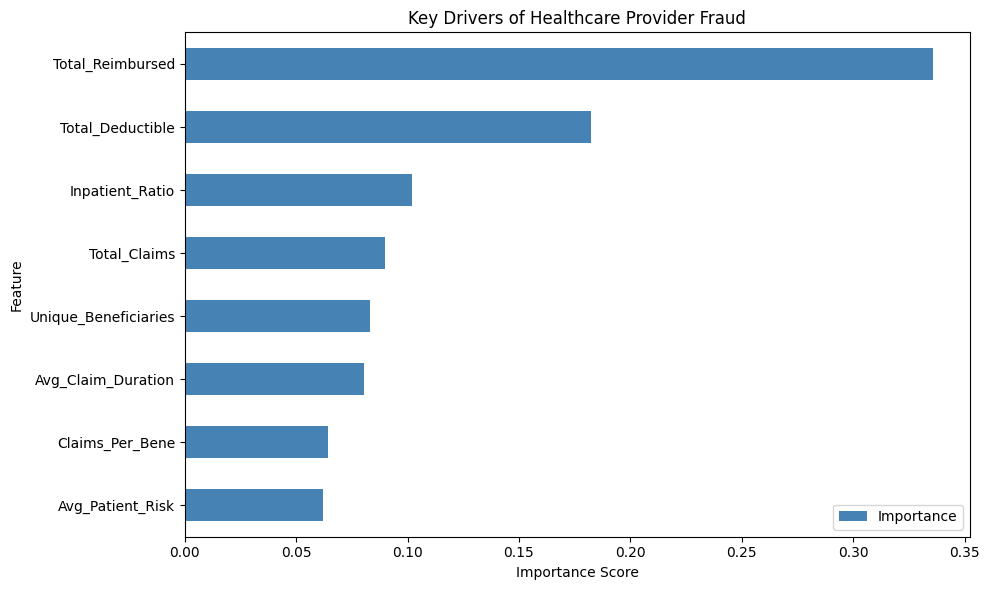

In [18]:
# STEP 18: Visualize feature importances using a horizontal bar chart
feature_importance_df.plot(kind='barh', x='Feature', y='Importance', figsize=(10, 6), color='steelblue')
plt.title('Key Drivers of Healthcare Provider Fraud')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Invert y-axis to ensure the highest importance feature appears at the top
plt.tight_layout()       # Ensures labels don't get cut off in standard viewers
plt.show()

In [19]:
# Save our cleaned, aggregated data to a CSV file
provider_data.to_csv('final_provider_fraud_data.csv', index=False)
print("Data saved successfully! Ready for Tableau/Power BI.")

Data saved successfully! Ready for Tableau/Power BI.
